## FTNCOCOA STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

ftncocoa=pd.read_csv('../stock_data/ftncocoa.csv') ## so it can be small letter. This is cool.
ftncocoa=ftncocoa.drop(columns=['high_price','low_price'])
ftncocoa.rename(columns={'trade_date':'date'},inplace=True)
ftncocoa['date']=pd.to_datetime(ftncocoa['date'])
ftncocoa['month']=ftncocoa['date'].dt.month
ftncocoa['quarter']=ftncocoa['date'].dt.quarter
ftncocoa['year']=ftncocoa['date'].dt.year

ftncocoa

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42779,FTNCOCOA,2017-01-03,0.50,0.50,0,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43339,FTNCOCOA,2017-01-04,0.50,0.50,0,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43449,FTNCOCOA,2017-01-05,0.50,0.50,0,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43559,FTNCOCOA,2017-01-06,0.50,0.50,0,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43649,FTNCOCOA,2017-01-09,0.50,0.50,0,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2258,298064,FTNCOCOA,2026-07-13,8.88,8.88,2320042,2026-07-13T15:10:02.995074+00:00,7,3,2026
2259,298502,FTNCOCOA,2026-07-14,8.21,8.21,2474885,2026-07-14T15:10:03.094441+00:00,7,3,2026
2260,298940,FTNCOCOA,2026-07-15,8.18,8.18,1814985,2026-07-15T15:10:03.078609+00:00,7,3,2026
2261,299378,FTNCOCOA,2026-07-16,8.25,8.25,1258089,2026-07-16T15:10:03.113936+00:00,7,3,2026


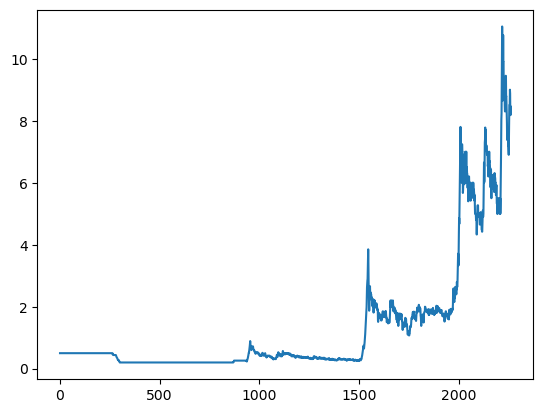

In [2]:
import matplotlib.pyplot as plt

plt.plot(ftncocoa['close_price'])
plt.show()

In [3]:
ftncocoa_end_month_df = (
    ftncocoa
    .sort_values("date")
    .groupby(ftncocoa["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

ftncocoa_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45349,FTNCOCOA,2017-01-31,0.50,0.50,0,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47170,FTNCOCOA,2017-02-28,0.50,0.50,0,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49286,FTNCOCOA,2017-03-31,0.50,0.50,0,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51114,FTNCOCOA,2017-04-28,0.50,0.50,11000,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53036,FTNCOCOA,2017-05-31,0.50,0.50,0,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35302,FTNCOCOA,2026-03-31,5.92,5.92,1164811,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281128,FTNCOCOA,2026-04-30,5.50,5.50,4160186,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284194,FTNCOCOA,2026-05-29,8.95,8.95,3077026,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294122,FTNCOCOA,2026-06-30,7.20,7.20,2298527,2026-06-30T15:10:03.08168+00:00,6,2,2026


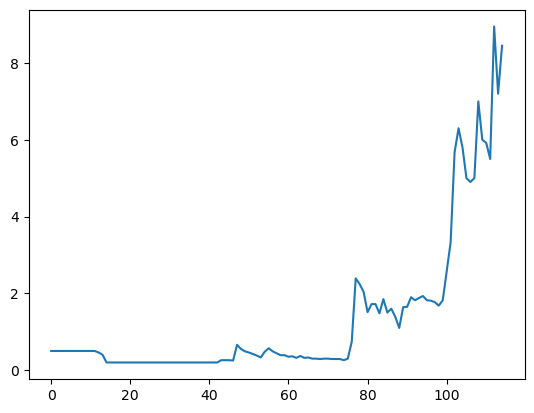

In [4]:
plt.plot(ftncocoa_end_month_df['close_price'])
plt.show()

In [5]:
ftncocoa_end_month_df['returns']=ftncocoa_end_month_df['close_price'].pct_change()*100
ftncocoa_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45349,FTNCOCOA,2017-01-31,0.50,0.50,0,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47170,FTNCOCOA,2017-02-28,0.50,0.50,0,2026-04-08T02:44:45.006295+00:00,2,1,2017,0.000000
2,49286,FTNCOCOA,2017-03-31,0.50,0.50,0,2026-04-08T02:45:42.281198+00:00,3,1,2017,0.000000
3,51114,FTNCOCOA,2017-04-28,0.50,0.50,11000,2026-04-08T02:51:55.619599+00:00,4,2,2017,0.000000
4,53036,FTNCOCOA,2017-05-31,0.50,0.50,0,2026-04-08T02:52:57.421655+00:00,5,2,2017,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
110,35302,FTNCOCOA,2026-03-31,5.92,5.92,1164811,2026-03-31T15:00:02.085058+00:00,3,1,2026,-1.333333
111,281128,FTNCOCOA,2026-04-30,5.50,5.50,4160186,2026-04-30T15:00:02.170664+00:00,4,2,2026,-7.094595
112,284194,FTNCOCOA,2026-05-29,8.95,8.95,3077026,2026-05-29T15:00:02.455558+00:00,5,2,2026,62.727273
113,294122,FTNCOCOA,2026-06-30,7.20,7.20,2298527,2026-06-30T15:10:03.08168+00:00,6,2,2026,-19.553073


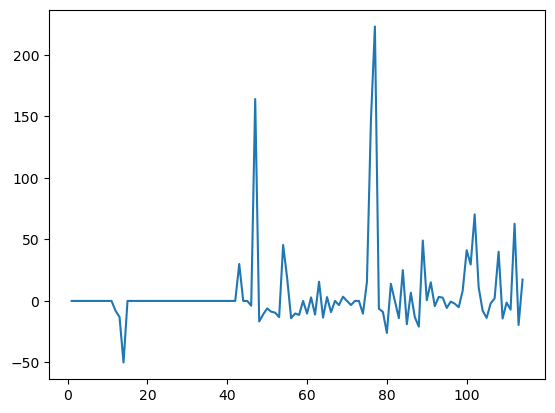

In [6]:
plt.plot(ftncocoa_end_month_df['returns'])
plt.show()

In [7]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(ftncocoa_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(-8.380282906539474, 2.520956014909771e-13, 0, 113, {'1%': -3.489589552580676, '5%': -2.887477210140433, '10%': -2.580604145195395}, 991.050154406781)
stationary


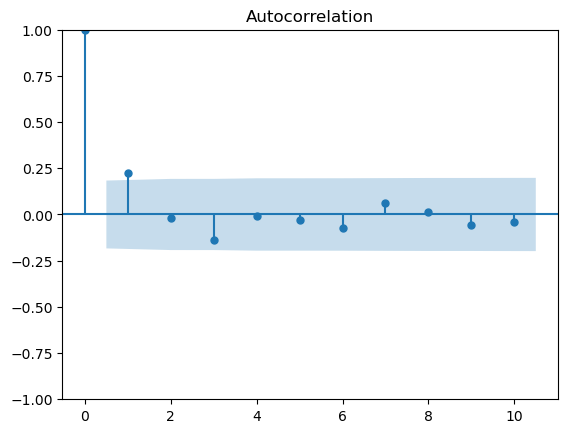

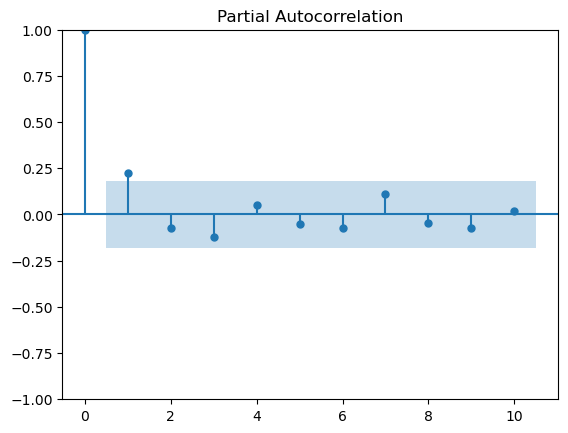

In [8]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(ftncocoa_end_month_df['returns'].dropna(), lags=10)
plot_pacf(ftncocoa_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [9]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=ftncocoa_end_month_df['close_price'][:-10]
test=ftncocoa_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -21.41975259452807]
[0, 0, 0, 0, 0, 1, -15.11875857447082]
[0, 0, 0, 0, 0, 2, -10.857800754083767]
[0, 0, 0, 0, 1, 0, -7.829804411693782]
[0, 0, 0, 0, 1, 1, -8.05391632867373]
[0, 0, 0, 0, 1, 2, -5.759647482771208]
[0, 0, 0, 0, 2, 0, -5.592245459703289]
[0, 0, 0, 0, 2, 1, -5.682860137090152]
[0, 0, 0, 0, 2, 2, -4.641409968235608]
[0, 0, 0, 1, 0, 0, -9.145329531766262]
[0, 0, 0, 1, 0, 1, -9.376204088476007]
[0, 0, 0, 1, 0, 2, -7.184498898173551]
[0, 0, 0, 1, 1, 0, -8.319792667085334]
[0, 0, 0, 1, 1, 1, -8.34302300532616]
[0, 0, 0, 1, 1, 2, -5.90584987252037]
[0, 0, 0, 1, 2, 0, -4.866797649093235]
[0, 0, 0, 1, 2, 1, -4.943267488696708]
[0, 0, 0, 1, 2, 2, -4.306000992253197]
[0, 0, 0, 2, 0, 0, -9.625589791872725]
[0, 0, 0, 2, 0, 1, -9.466977054785943]
[0, 0, 0, 2, 0, 2, -7.443503523645832]
[0, 0, 0, 2, 1, 0, -6.025438541717027]
[0, 0, 0, 2, 1, 1, -6.037176325917787]
[0, 0, 0, 2, 1, 2, -5.5692865932176545]
[0, 0, 0, 2, 2, 0, -4.97875752267432]
[0, 0, 0, 2, 2, 1, -4.40455

In [10]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
103,0,1,0,2,1,1,-127.642395
280,1,0,1,1,0,1,-21.919636
0,0,0,0,0,0,0,-21.419753
27,0,0,1,0,0,0,-20.325556
54,0,0,2,0,0,0,-19.924772
...,...,...,...,...,...,...,...
679,2,2,1,0,1,2,0.488918
688,2,2,1,1,1,2,0.489603
697,2,2,1,2,1,2,0.490180
455,1,2,1,2,1,2,0.491781


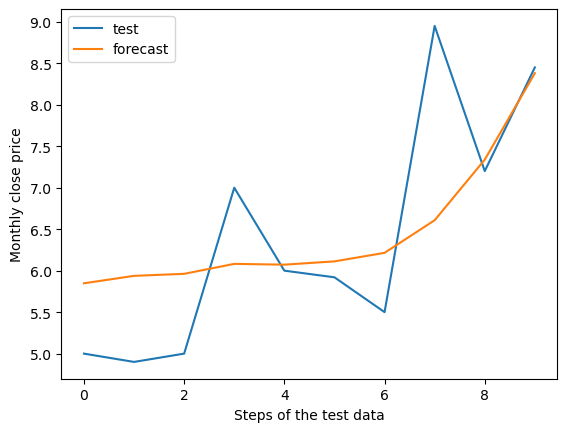

r2_score:  0.4953658589106842
rmse:  0.9811103469582223
description:  count    115.000000
mean       1.333043
std        1.938497
min        0.200000
25%        0.225000
50%        0.460000
75%        1.700000
max        8.950000
Name: close_price, dtype: float64


In [11]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

y_train=ftncocoa_end_month_df['close_price'][:-10]
y_test=ftncocoa_end_month_df['close_price'][-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(0,2,2), 
seasonal_order=(2,1,2,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', ftncocoa_end_month_df.close_price.describe())

Its not capturing the variations properly. Lets try the returns

In [12]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=ftncocoa_end_month_df['returns'].dropna()[:-10]
test=ftncocoa_end_month_df['returns'].dropna()[-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -0.06554644561929801]
[0, 0, 0, 0, 0, 1, -0.010498776039654878]
[0, 0, 0, 0, 0, 2, -0.03481898290252938]
[0, 0, 0, 0, 1, 0, -0.2920525373592666]
[0, 0, 0, 0, 1, 1, -0.18881679623644088]
[0, 0, 0, 0, 1, 2, -0.15280282011268875]
[0, 0, 0, 0, 2, 0, -2.902368505879415]
[0, 0, 0, 0, 2, 1, -0.47852176288197334]
[0, 0, 0, 0, 2, 2, -1.6449886381535808]
[0, 0, 0, 1, 0, 0, -0.006375769612285254]
[0, 0, 0, 1, 0, 1, -0.006218898619551494]
[0, 0, 0, 1, 0, 2, -0.10985475580701531]
[0, 0, 0, 1, 1, 0, -0.2456396426187646]
[0, 0, 0, 1, 1, 1, -0.14659748965771557]
[0, 0, 0, 1, 1, 2, -0.19178306217863517]
[0, 0, 0, 1, 2, 0, -3.0223824001030337]
[0, 0, 0, 1, 2, 1, -0.3553632290290909]
[0, 0, 0, 1, 2, 2, -1.53398263937732]
[0, 0, 0, 2, 0, 0, -0.03007196535360368]
[0, 0, 0, 2, 0, 1, -0.09497317681396988]
[0, 0, 0, 2, 0, 2, -0.16829922270065567]
[0, 0, 0, 2, 1, 0, -1.784046166280171]
[0, 0, 0, 2, 1, 1, -0.14434742395285238]
[0, 0, 0, 2, 1, 2, -0.13162697629506925]
[0, 0, 0, 2, 2, 0, -1.028

In [13]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
652,2,2,0,0,2,0,-148.335579
416,1,2,0,1,0,2,-104.456325
424,1,2,0,2,0,1,-101.833189
425,1,2,0,2,0,2,-99.306743
407,1,2,0,0,0,2,-91.262933
...,...,...,...,...,...,...,...
396,1,1,2,2,0,0,0.079196
604,2,1,1,1,0,2,0.079288
369,1,1,1,2,0,0,0.079527
595,2,1,1,0,0,2,0.079816


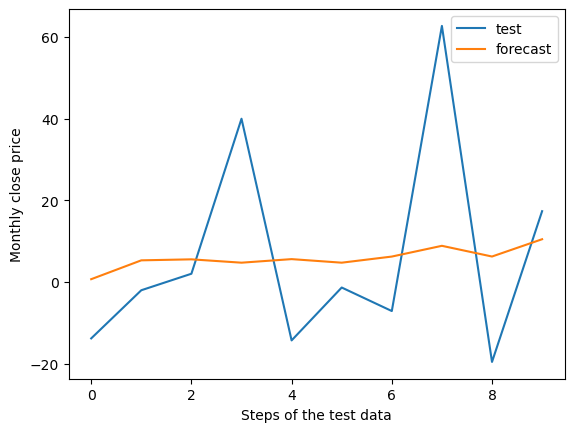

r2_score:  0.0829538767345337
rmse:  23.964675384058122
description:  count    114.000000
mean       5.604768
std       32.984706
min      -50.000000
25%       -6.016707
50%        0.000000
75%        0.000000
max      222.972973
Name: returns, dtype: float64


In [14]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

y_train=ftncocoa_end_month_df['returns'].dropna()[:-10]
y_test=ftncocoa_end_month_df['returns'].dropna()[-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(2,1,1), 
seasonal_order=(2,0,0,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', ftncocoa_end_month_df.returns.dropna().describe())

Very horrible. We will look on more ways
